In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # 분류 모델로 변경
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


import joblib

In [122]:
# 데이터 로드 및 전처리
df = pd.read_csv('dataset/heart_disease_uci_korean.csv', encoding='cp949')
df = df.drop(columns=['주요 혈관 수', '심장 혈류 상태'])  # 결측이 과도한 컬럼 삭제

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 임상적으로 0이 나올 수 없는 값은 '미기록·결측'으로 간주 (UCI 심장 데이터 관행)
# ※ 운동 후 심전도 저하(oldpeak)=0 은 '저하 없음'으로 의미가 있을 수 있어 여기서 지우지 않음
cols_zero_as_missing = ['안정 시 혈압', '콜레스테롤', '최대 심박수']
for col in cols_zero_as_missing:
    if col in df.columns:
        df.loc[df[col] == 0, col] = np.nan

In [123]:
# 결측치 처리
label_col = '심장병 진단 결과'
if label_col in df.columns:
    df = df.dropna(subset=[label_col])

# 수치형: 중앙값(이상치에 덜 민감). 라벨 열은 평균/중앙값으로 채우지 않음
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if col == label_col:
        continue
    df[col] = df[col].fillna(df[col].median())

# 문자열: 최빈값
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    if col == label_col:
        continue
    mode_val = df[col].mode()
    if len(mode_val) > 0:
        df[col] = df[col].fillna(mode_val.iloc[0])

# fillna 후 일부 열이 bool로 바뀌면 라벨 인코딩에서 빠질 수 있음 → 문자열 고정
for col in ('공복 혈당 여부', '운동 유발성 협심증'):
    if col in df.columns:
        df[col] = df[col].astype(str)

C:\Users\human-27\AppData\Local\Temp\ipykernel_33844\3201792816.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val.iloc[0])


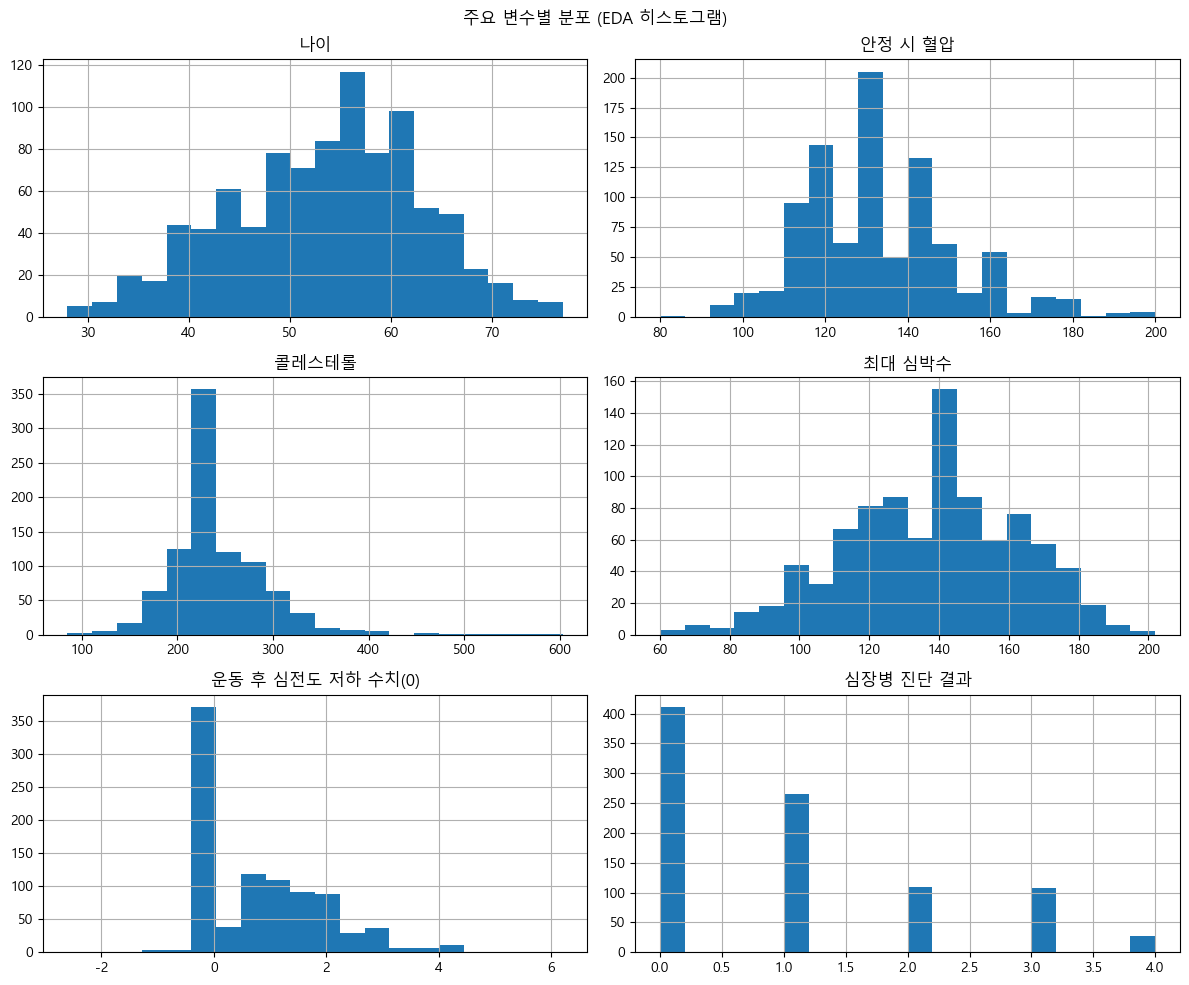

In [124]:
# 수치형 변수들이 정규분포를 따르는지 확인하는 절차 
eda_numeric = [c for c in df.select_dtypes(include=['number']).columns if c != 'target']
df[eda_numeric].hist(figsize=(12, 10), bins=20)
plt.suptitle('주요 변수별 분포 (EDA 히스토그램)')
plt.tight_layout()
plt.show()

In [125]:
# Feature Engineering
# 나이 대비 혈압 비율
df['나이 대비 혈압 비율'] = df['안정 시 혈압'] / df['나이']
# 고령자 여부 (60세 이상)
df['고령자 여부'] = (df['나이'] >= 60).astype(int)
# 최대 심박수 대비 현재 혈압 비율
df['최대 심박수 대비 현재 혈압 비율'] = df['최대 심박수'] / df['안정 시 혈압']

# inf/NaN은 파생변수에만 중앙값 보정 (전체 df에 0으로 채우면 콜레스테롤 등이 다시 '가짜 0'이 됨)
for _col in ['나이 대비 혈압 비율', '최대 심박수 대비 현재 혈압 비율']:
    df[_col] = df[_col].replace([np.inf, -np.inf], np.nan)
    df[_col] = df[_col].fillna(df[_col].median())

# 타겟 변수 이진화 (0: 정상, 1: 질환)
df['target'] = (df['심장병 진단 결과'] > 0).astype(int)

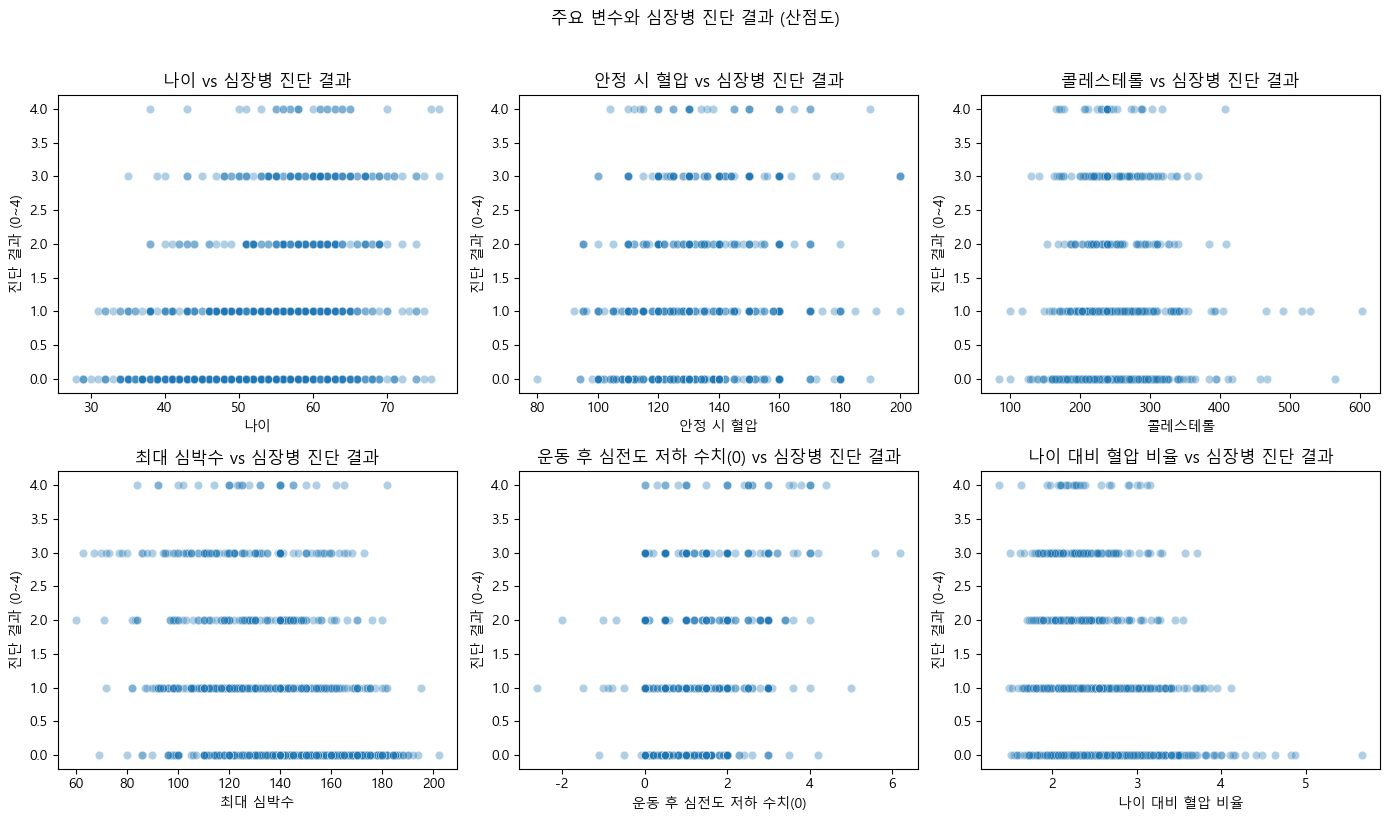

In [126]:
# y축: 심장병 진단 결과(0~4) — 단계가 보이도록. 이진 target만 쓸 때는 아래 대안 주석 참고.
scatter_x = [
    '나이',
    '안정 시 혈압',
    '콜레스테롤',
    '최대 심박수',
    '운동 후 심전도 저하 수치(0)',
    '나이 대비 혈압 비율',
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, scatter_x):
    sns.scatterplot(
        data=df,
        x=col,
        y='심장병 진단 결과',
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f'{col} vs 심장병 진단 결과')
    ax.set_ylabel('진단 결과 (0~4)')
plt.suptitle('주요 변수와 심장병 진단 결과 (산점도)', y=1.02)
plt.tight_layout()
plt.show()

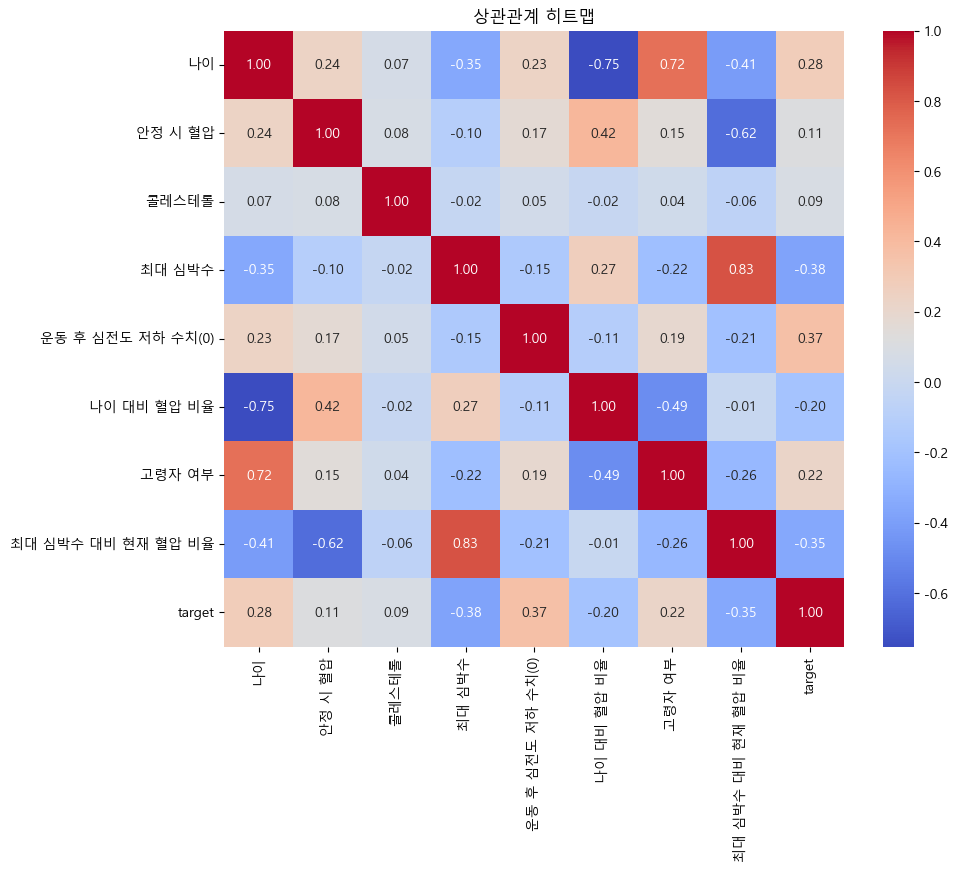

In [127]:
# 히트맵 분석 (타겟은 target만 — 심장병 진단 결과 열은 상관행렬에서 제외)
plt.figure(figsize=(10, 8))
exclude_from_corr = {'심장병 진단 결과'}
numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c not in exclude_from_corr]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('상관관계 히트맵')
plt.show()

In [128]:
# 라벨 인코딩 
categorical_cols = df.select_dtypes(include=['object']).columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [129]:
# Feature/Target X, y 분리
# 원본 타겟과 파생 타겟을 제외한 나머지를 X로
X = df.drop(['심장병 진단 결과', 'target'], axis=1)
y = df['target']

In [130]:
# 데이터 분할 (정확하게 정답 컬럼들만 제외)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [131]:
# 스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 모델 리스트 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42)
}
# 루프 돌리면서 비교
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled) # 예측값 먼저 뽑기
    
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n {name} 정확도: {acc:.4f}, 재현율: {recall:.4f}, F1 점수: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print("="*50)

d:\python_sim\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
d:\python_sim\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



 Logistic Regression 정확도: 0.7772, 재현율: 0.7941, F1 점수: 0.7980
              precision    recall  f1-score   support

           0       0.75      0.76      0.75        82
           1       0.80      0.79      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.78      0.78       184


 Decision Tree 정확도: 0.6196, 재현율: 0.6863, F1 점수: 0.6667
              precision    recall  f1-score   support

           0       0.58      0.54      0.56        82
           1       0.65      0.69      0.67       102

    accuracy                           0.62       184
   macro avg       0.61      0.61      0.61       184
weighted avg       0.62      0.62      0.62       184


 Random Forest 정확도: 0.7283, 재현율: 0.5882, F1 점수: 0.7059
              precision    recall  f1-score   support

           0       0.64      0.90      0.75        82
           1       0.88      0.59      0.71       102

    accu

d:\python_sim\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:

# 모델 정의 
lr_model = LogisticRegression(random_state=42, max_iter=5000, class_weight='balanced')
lr_model.fit(X_train, y_train)


# 하이퍼파라미터 그리드 설정
# C는 규제 강도: 작을수록 강한 규제(모델이 단순해짐), 클수록 약한 규제(데이터에 밀착)
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"], # 로지스틱 회귀의 표준 규제 방식
    "solver": ["lbfgs"], # 소규모 데이터셋에 최적화된 계산 엔진
}

# GridSearchCV 실행
grid = GridSearchCV(
    lr_model,          # 학습할 모델
    param_grid,       # 시도할 파라미터 조합
    cv=5,             # 5-폴드 교차 검증 (데이터를 5등분해서 돌려막기 학습)
    scoring="recall",     # 심장 질환 특성상 실제 환자를 놓치지 않는 재현율 기준으로 최적 모델 선발
    n_jobs=-1,        # 내 컴퓨터의 모든 코어(CPU)를 사용하여 병렬 연산
    refit=True,       # 가장 좋은 파라미터로 전체 데이터를 다시 학습
)

# 최적의 조합 찾기 시작
grid.fit(X_train_scaled, y_train)

# 결과 출력
print(f"GridSearchCV 최적 하이퍼파라미터: {grid.best_params_}")
print(f"교차검증 최고 F1 점수: {grid.best_score_:.4f}")

# 최적 모델로 예측 및 최종 평가
best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n[테스트 세트] 최적 모델 성능 - 정확도: {acc:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}")
print("-" * 60)
print(classification_report(y_test, y_pred))

GridSearchCV 최적 하이퍼파라미터: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
교차검증 최고 F1 점수: 0.7737

[테스트 세트] 최적 모델 성능 - 정확도: 0.7935, 재현율: 0.7941, F1: 0.8100
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        82
           1       0.83      0.79      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



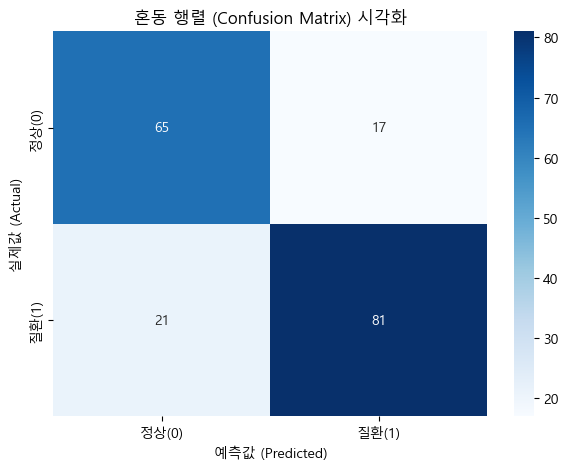

In [ ]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['정상(0)', '질환(1)'], 
            yticklabels=['정상(0)', '질환(1)'])
plt.title('혼동 행렬 (Confusion Matrix) 시각화')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')
plt.show()

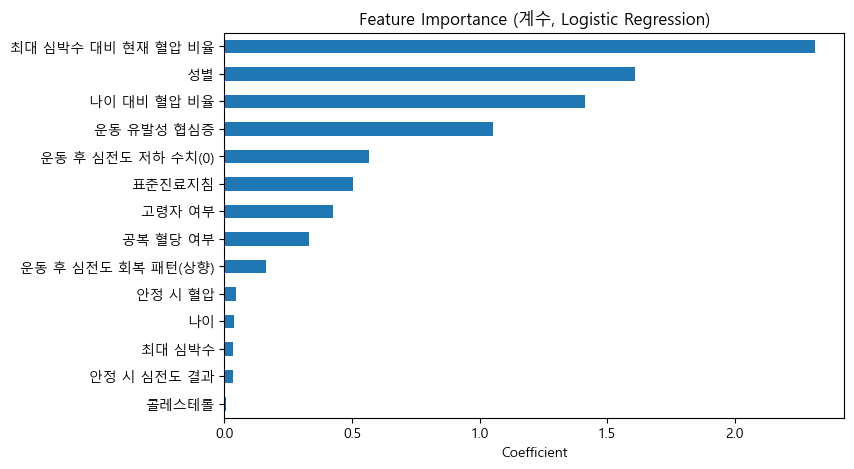

In [134]:
# 변수 중요도 (Logistic Regression: 계수 절댓값 기준)
coef_abs = pd.Series(np.abs(best_lr.coef_[0]), index=X.columns)

plt.figure(figsize=(8, 5))
coef_abs.sort_values().plot(kind='barh')
plt.title("Feature Importance (계수, Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

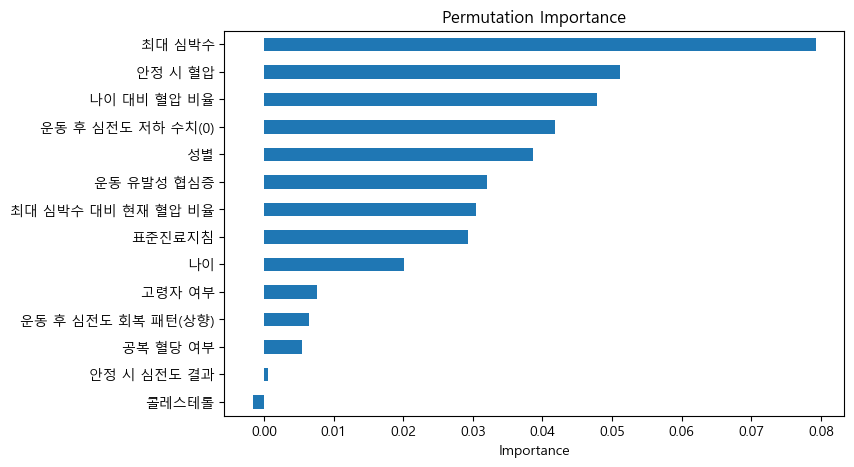

In [ ]:
# Permutation Importance
perm = permutation_importance(
    best_lr, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42
)
perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
# 11. 모델 저장
joblib.dump(best_lr, "model/heart_model.pkl")
joblib.dump(scaler, "model/heart_scaler.pkl")
joblib.dump(encoders, "model/heart_encoders.pkl")

['model/heart_encoders.pkl']